# Exploratory Data Analysis (EDA)

## Dataset
AI4I 2020 Predictive Maintenance

## Objective

The objective of this notebook is to explore the dataset, identify patterns, detect anomalies, understand feature relationships, and prepare the data for feature engineering and machine learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\rajes\OneDrive\Projects\Manufacturing-intelligence-platform\data\raw\predictive_maintenance\ai4i2020.csv")

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [4]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [5]:
(df["Machine failure"].value_counts(normalize=True) * 100).round(2)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [6]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

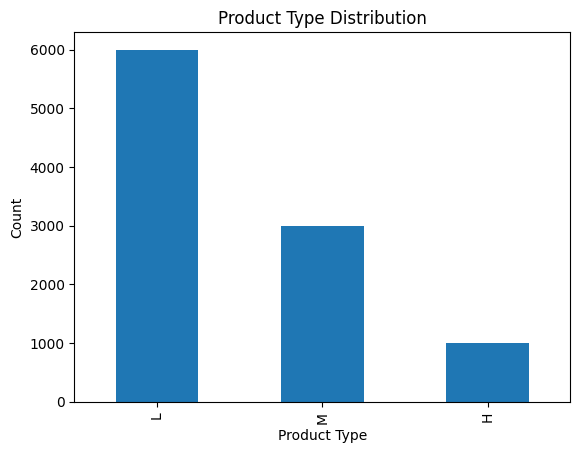

In [7]:
df["Type"].value_counts().plot(kind="bar")

plt.title("Product Type Distribution")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.show()

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


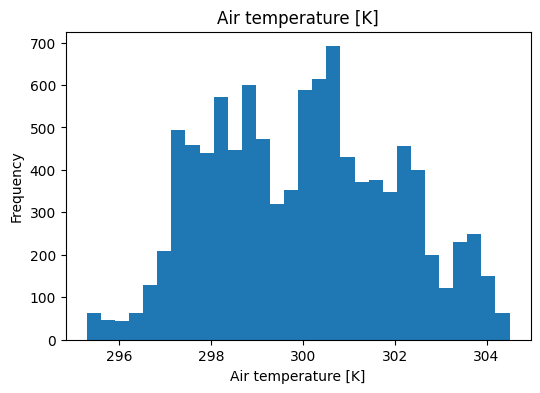

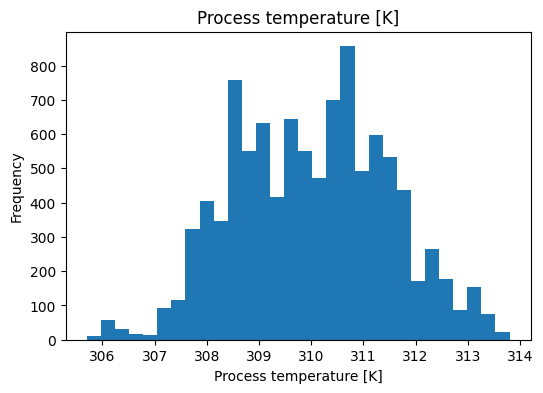

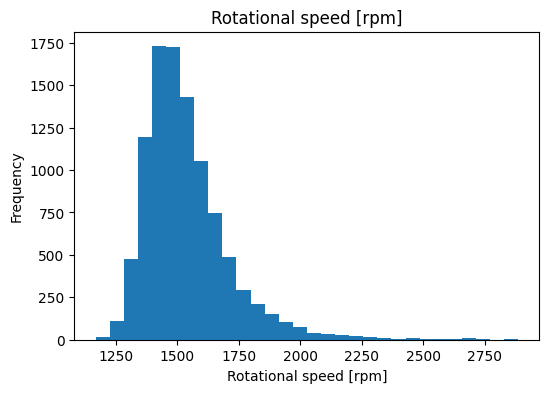

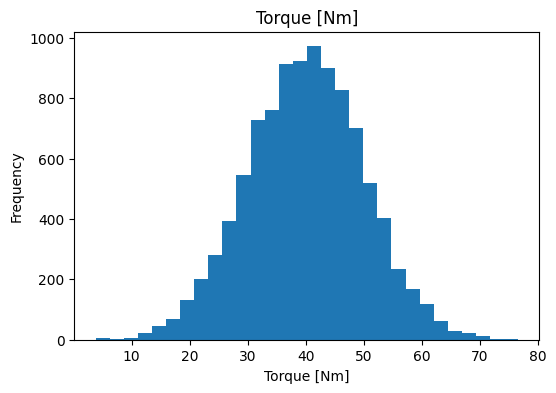

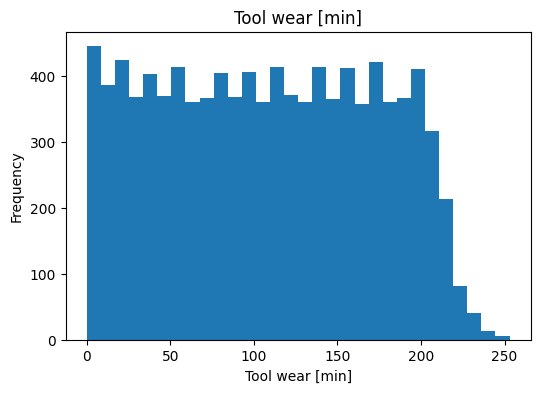

In [9]:
columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

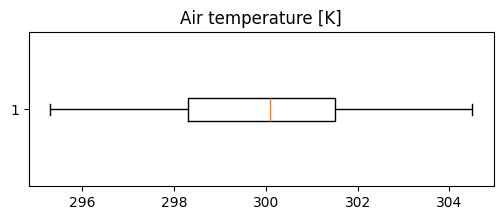

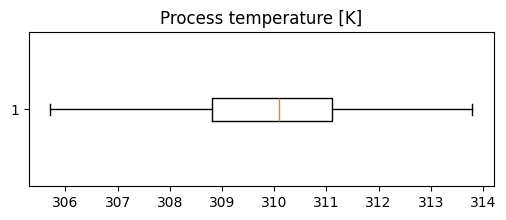

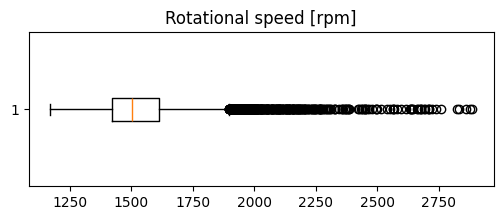

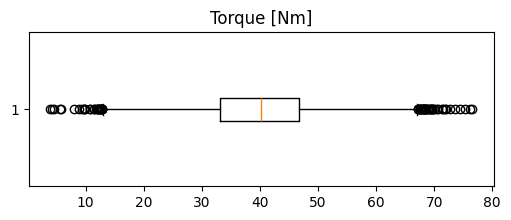

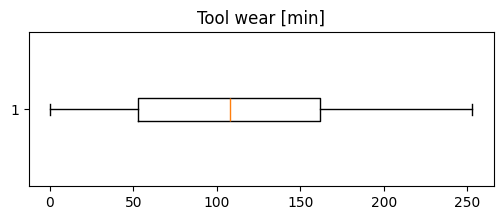

In [10]:
for col in columns:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

In [11]:
numeric_df = df.select_dtypes(include=np.number)

In [12]:
corr = numeric_df.corr()

corr

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


In [13]:
failure_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_columns].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Relationship Between Features and Target
These comparisons give intuition about which features may influence failures.

In [14]:
df.groupby("Machine failure")["Tool wear [min]"].mean()

Machine failure
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64

## EDA Summary

- Dataset contains 10,000 records and 14 features.
- No missing values or duplicate records.
- Machine failures are relatively rare, indicating class imbalance.
- Product Type L is the most common category.
- Numerical features show different distributions.
- Tool wear and torque appear related to machine failures.
- Failure type columns provide additional insights into maintenance events.